# ECOM Solar Radiation Pressure

Solar radiation pressure (SRP) is the largest non-gravitational force on a GNSS satellite, and the hardest to model physically: it depends on the spacecraft's shape, surface properties, thermal state and attitude law. The **Empirical CODE Orbit Model (ECOM)** sidesteps all of that by writing the SRP acceleration in a Sun-oriented satellite frame as a small set of constant and once-per-revolution coefficients that are *estimated* from tracking data rather than derived from a surface model. It is what CODE and most IGS analysis centres use for precise GNSS orbits.

This tutorial

1. downloads a month of IGS final GPS orbits (SP3) for one satellite,
2. fits an initial state plus ECOM coefficients to the first three days with `scipy.optimize.least_squares`,
3. propagates forward with the fitted coefficients and measures the error against the SP3 truth for the cannonball model, the reduced 5-parameter ECOM, and the 9-parameter ECOM2.

The model, the DYB frame, the sign and eclipse conventions, and the parameter sets are described in the [Force Model guide](../guide/forces.md#empirical-code-orbit-model-ecom); the API is [`satkit.ecomparams`](../api/satprop.md#satkit.ecomparams). In short: with $\hat e_D$ pointing from the satellite **to the Sun**, $\hat e_Y = \hat e_D \times \hat r$ along the solar-panel axis and $\hat e_B = \hat e_D \times \hat e_Y$,

$$\vec a = \nu\left[D(\varphi)\,\hat e_D + Y(\varphi)\,\hat e_Y + B(\varphi)\,\hat e_B\right]$$

where $\nu$ is the Earth-shadow factor, $\varphi$ is the argument of latitude $u$ (ECOM1) or $\Delta u$ from orbit noon (ECOM2), and the physical $D_0$ is *negative*, about $-10^{-7}$ m/s² for a GPS satellite.

**Runtime and data.** The fits below take a few seconds to a minute each (finite-difference Jacobians over a few hundred propagations), and the data are ~32 daily files (~1 MB each) fetched from BKG's public IGS mirror. The notebook is committed with its outputs and is not re-executed by the documentation build.


In [1]:
import datetime as dt
import gzip
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
import scienceplots  # noqa: F401  (registers the "science" style)
from scipy.optimize import least_squares
from scipy.optimize._numdiff import approx_derivative

import satkit as sk

plt.style.use(["science", "no-latex", "../satkit.mplstyle"])

PRN = 20                      # GPS satellite (PRN G20)
START = dt.date(2024, 1, 1)   # first day of the window
FIT_DAYS = 3                  # length of the fit arc
PROP_DAYS = 30                # length of the prediction
CACHE = Path(os.environ.get("SP3_CACHE", "sp3-cache"))  # where SP3 files are kept

## Truth: IGS final orbits

The IGS final combined product gives satellite centre-of-mass positions in the ITRF every 15 minutes, accurate to ~2.5 cm. Daily files are named `IGS0OPSFIN_<year><doy>0000_01D_15M_ORB.SP3` under the GPS-week directory on the BKG mirror (no login required). We read one PRN, drop any flagged epochs, and rotate the positions into the GCRF with the full IAU 2006/2000A transform — the frame in which `satkit.propagate` works.

SP3 epochs are in **GPS time** (header line `%c ... GPS`), 18 s ahead of UTC in 2024, so they are read with `scale=sk.timescale.GPS`. Reading them as UTC is a classic mistake: the ITRF→GCRF rotation of the truth is then off by 18 s of Earth rotation (1.3 mrad) relative to the Sun/Moon geometry — the orbit stays self-consistent, so nothing looks obviously wrong, but the fit residual quadruples.

In [2]:
GPS_EPOCH = dt.date(1980, 1, 6)
BKG = "https://igs.bkg.bund.de/root_ftp/IGS/products"


def fetch_sp3(day: dt.date) -> Path:
    """Download (once) the IGS final SP3 for `day` into CACHE."""
    doy = day.timetuple().tm_yday
    name = f"IGS0OPSFIN_{day.year}{doy:03d}0000_01D_15M_ORB.SP3"
    out = CACHE / name
    if not out.exists():
        week = (day - GPS_EPOCH).days // 7
        r = requests.get(f"{BKG}/{week}/{name}.gz", timeout=120)
        r.raise_for_status()
        CACHE.mkdir(parents=True, exist_ok=True)
        out.write_bytes(gzip.decompress(r.content))
    return out


def read_sp3(path: Path, prn: int):
    """(times, ITRF positions in m) for one GPS PRN; bad epochs dropped."""
    times, pos, current = [], [], None
    for line in open(path):
        if line.startswith("*"):
            y, mo, d, h, mi = int(line[3:7]), int(line[8:10]), int(line[11:13]), int(line[14:16]), int(line[17:19])
            current = sk.time(y, mo, d, h, mi, float(line[20:31]), scale=sk.timescale.GPS)  # SP3 epochs are GPS time
        elif line.startswith(f"PG{prn:02d}") and current is not None:
            x, y_, z = float(line[4:18]), float(line[18:32]), float(line[32:46])
            if any(abs(v) > 900000.0 for v in (x, y_, z)) or (x == 0.0 and y_ == 0.0):
                continue
            times.append(current)
            pos.append([x, y_, z])
    return times, np.array(pos) * 1e3


def load_truth(start: dt.date, ndays: int, prn: int):
    """Concatenate daily files into GCRF truth (times, positions in m)."""
    times, pos = [], []
    for i in range(ndays):
        t, p = read_sp3(fetch_sp3(start + dt.timedelta(days=i)), prn)
        for tt, pp in zip(t, p):
            if times and tt == times[-1]:  # duplicate day-boundary epoch
                continue
            times.append(tt)
            pos.append(pp)
    pos = np.array(pos)
    gcrf = np.array([sk.frametransform.qitrf2gcrf(t) * p for t, p in zip(times, pos)])
    return times, gcrf


times, truth = load_truth(START, PROP_DAYS + 1, PRN)
n_fit = sum(1 for t in times if t <= times[0] + sk.duration.from_days(FIT_DAYS))
print(f"G{PRN:02d}: {len(times)} epochs, {times[0]} → {times[-1]}; fitting on the first {n_fit}")

# Is this an eclipse season for this satellite? (cylindrical shadow test)
in_shadow = 0
for t, p in zip(times, truth):
    s_hat = sk.sun.pos_gcrf(t)
    s_hat = s_hat / np.linalg.norm(s_hat)
    along = p @ s_hat
    if along < 0 and np.linalg.norm(p - along * s_hat) < sk.consts.earth_radius:
        in_shadow += 1
print(f"epochs in Earth shadow: {in_shadow} ({'eclipse season' if in_shadow else 'none — no eclipses in this window'})")

G20: 2976 epochs, 2023-12-31T23:59:42.000000Z → 2024-01-31T23:44:42.000000Z; fitting on the first 289
epochs in Earth shadow: 0 (none — no eclipses in this window)


## Force model and SRP variants

Everything except SRP is the same for all three variants: EGM96 to degree and order 12 (more than enough at 26,600 km), Sun and Moon, solid Earth tides, relativity. The variants differ only in the `satproperties` passed to `propagate`:

| variant | free coefficients | `satproperties` |
|---|---|---|
| cannonball | $C_R A/m$ (m²/kg) | `satproperties(craoverm=c)` |
| ECOM reduced | $D_0, Y_0, B_0, B_c, B_s$ (m/s²) | `satproperties(craoverm=0, ecom=ecomparams.reduced(...))` |
| ECOM2 | $D_0, Y_0, B_0, B_{1c}, B_{1s}, D_{2c}, D_{2s}, D_{4c}, D_{4s}$ | `satproperties(craoverm=0, ecom=ecomparams.ecom2(...))` |

`craoverm=0` makes ECOM the *whole* SRP model rather than a correction on top of the cannonball. Coefficients are handled in nm/s² inside the fit so that all parameters are O(1–100).

Two setup notes. This window has no eclipses (checked above); for an arc that crosses Earth's shadow use `settings.integrator = sk.integrator.gauss_jackson8`, because the adaptive Runge–Kutta steppers can abort at a shadow boundary with *too many consecutive step rejections* (the fixed-step multistep integrator is immune, and fits an eclipsing satellite just as well — see the benchmark below). And keep the default `egm96` gravity model with `solid_step1` tides: EGM96 is a *tide-free* model, whereas `jgm3` and `itugrace16` are *zero-tide*; adding Step-1 solid tides (which include the permanent tide) to a zero-tide model double-counts it, ~5–7 cm cross-track over 3 days at GPS altitude.

In [3]:
settings = sk.propsettings()
settings.gravity_degree = 12
settings.gravity_order = 12
settings.use_sun_gravity = True
settings.use_moon_gravity = True
settings.tide_model = sk.tidemodel.solid_step1
settings.use_relativistic_correction = True
settings.use_spaceweather = False      # no drag at GPS altitude
settings.abs_error = settings.rel_error = 1e-11
settings.enable_interp = True          # so one propagation can be sampled at every SP3 epoch

# name: (initial coefficients, absolute finite-difference step per coefficient, builder)
VARIANTS = {
    "cannonball": ([0.02], [1e-3], lambda c: sk.satproperties(craoverm=c[0])),
    "ecom-reduced": (
        [-100.0, 0, 0, 0, 0], [0.1] * 5,
        lambda c: sk.satproperties(craoverm=0.0, ecom=sk.ecomparams.reduced(*(np.asarray(c) * 1e-9))),
    ),
    "ecom2": (
        [-100.0] + [0.0] * 8, [0.1] * 9,
        lambda c: sk.satproperties(craoverm=0.0, ecom=sk.ecomparams.ecom2(*(np.asarray(c) * 1e-9))),
    ),
}


def propagate_states(x, build, t0, t1, at_times):
    """Propagate [x,y,z (km), vx,vy,vz (m/s), coeffs...] and sample at `at_times`."""
    state = np.concatenate((x[:3] * 1e3, x[3:6]))
    res = sk.propagate(state, t0, t1, propsettings=settings, satproperties=build(x[6:]))
    return np.array(res.interp(at_times))

## Fit: initial state + SRP coefficients

The unknowns are the GCRF state at the first epoch (position in km, velocity in m/s, so the parameters are similarly scaled) and the SRP coefficients. The residual is the propagated-minus-truth position at every SP3 epoch in the fit arc; `least_squares` builds a finite-difference Jacobian, so each iteration costs one propagation per parameter.

Two practical details: the initial velocity is seeded by differencing the first two truth points, and the finite-difference steps are set explicitly — scipy's default relative step on a coefficient whose current value is *zero* is far below the integrator's noise floor.

The Jacobian is finite-differenced with **absolute** steps (1 m, 0.1 mm/s, 0.1 nm/s²): scipy's `diff_step` is relative and silently falls back to √ε for parameters that are currently zero, which is far below integrator noise for the harmonic ECOM terms. The initial velocity comes from a five-point one-sided stencil (a two-point chord over a 15-min step is ~250 m/s off at GPS altitude).

In [4]:
def initial_velocity(t, p):
    """O(dt^4) one-sided stencil from the first five positions."""
    h = (t[1] - t[0]).seconds
    return (-25 * p[0] + 48 * p[1] - 36 * p[2] + 16 * p[3] - 3 * p[4]) / (12 * h)


def fit(variant, tf, pf):
    c0, cstep, build = VARIANTS[variant]
    x0 = np.concatenate((pf[0] / 1e3, initial_velocity(tf, pf), c0))
    steps = np.array([1e-3] * 3 + [1e-4] * 3 + cstep)  # km, m/s, coefficient units

    def resid(x):
        return (propagate_states(x, build, tf[0], tf[-1], tf)[:, :3] - pf).ravel()

    sol = least_squares(resid, x0, jac=lambda x: approx_derivative(resid, x, abs_step=steps),
                        x_scale="jac", ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=400)
    return sol.x, np.sqrt(np.mean(np.sum(sol.fun.reshape(-1, 3) ** 2, axis=1)))  # 3D RMS


fits = {}
for name in VARIANTS:
    x, rms = fit(name, times[:n_fit], truth[:n_fit])
    fits[name] = x
    unit = "m²/kg" if name == "cannonball" else "nm/s²"
    print(f"{name:13s} fit RMS {rms:6.3f} m (3D)   coefficients ({unit}): "
          + ", ".join(f"{c:8.3f}" for c in x[6:]))

cannonball    fit RMS  3.812 m (3D)   coefficients (m²/kg):    0.023


ecom-reduced  fit RMS  0.050 m (3D)   coefficients (nm/s²): -105.768,    0.969,    0.561,   -0.179,   -0.465


ecom2         fit RMS  0.048 m (3D)   coefficients (nm/s²): -106.042,    0.971,    0.556,    0.771,    0.172,   -1.570,    0.010,    1.197,   -0.232


The ECOM fits sit at the accuracy of the IGS final orbits themselves (~2.5 cm per axis, i.e. ~4 cm 3D), some 75× tighter than the cannonball, and the coefficients are physical: $D_0 \approx -106$ nm/s² is the expected $-P_\odot\,C_R A/m$ for $C_R A/m \approx 0.023$ m²/kg (which is what the cannonball fit found), and the Y and B terms are below 1 nm/s². The reduced 5-parameter set and the 9-parameter ECOM2 give the same answer here — for a cube-like GPS bus the extra harmonics add nothing.

## Prediction: propagate a month with the fitted coefficients

From each fitted state and coefficient set, propagate over the whole window in one call and compare with the truth at every epoch. The RTN decomposition tells us *where* the error goes.

In [5]:
def rtn(pos, vel, d):
    r_hat = pos / np.linalg.norm(pos)
    n_hat = np.cross(pos, vel); n_hat /= np.linalg.norm(n_hat)
    return np.array([d @ r_hat, d @ np.cross(n_hat, r_hat), d @ n_hat])


tdays = np.array([(t - times[0]).days for t in times])  # duration.days is fractional
results = {}
for name, x in fits.items():
    st = propagate_states(x, VARIANTS[name][2], times[0], times[-1], times)
    d = st[:, :3] - truth
    results[name] = (np.linalg.norm(d, axis=1), np.array([rtn(s[:3], s[3:], dd) for s, dd in zip(st, d)]))

print(f"3D RMS error (m) on day N          {'1':>7} {'3':>7} {'7':>7} {'14':>7} {'21':>7} {'30':>7}     R/T/N rms on day 30 (m)")
for name, (err, comp) in results.items():
    cells_ = []
    for day in (1, 3, 7, 14, 21, 30):
        m = (tdays >= day - 1) & (tdays < day)
        cells_.append(f"{np.sqrt(np.mean(err[m] ** 2)):7.2f}")
    m = (tdays >= PROP_DAYS - 1) & (tdays < PROP_DAYS)
    rr = np.sqrt(np.mean(comp[m] ** 2, axis=0))
    print(f"{name:13s}                    " + " ".join(cells_) + f"     {rr[0]:6.1f} / {rr[1]:7.1f} / {rr[2]:5.1f}")

for name, (err, _) in results.items():
    above = np.nonzero(err[n_fit:] > 10.0)[0]
    print(f"{name:13s} first epoch above 10 m: day {tdays[n_fit + above[0]]:.1f}" if above.size else f"{name:13s} never above 10 m")

3D RMS error (m) on day N                1       3       7      14      21      30     R/T/N rms on day 30 (m)
cannonball                          3.81    3.72  143.22  869.20 2267.23 5126.79       21.1 /  5126.7 /   5.9
ecom-reduced                        0.06    0.05    0.76   13.10   36.58   97.82        3.3 /    97.8 /   0.8
ecom2                               0.06    0.04    0.74   12.88   35.90   95.86        3.5 /    95.8 /   0.8
cannonball    first epoch above 10 m: day 3.1
ecom-reduced  first epoch above 10 m: day 12.3
ecom2         first epoch above 10 m: day 12.4


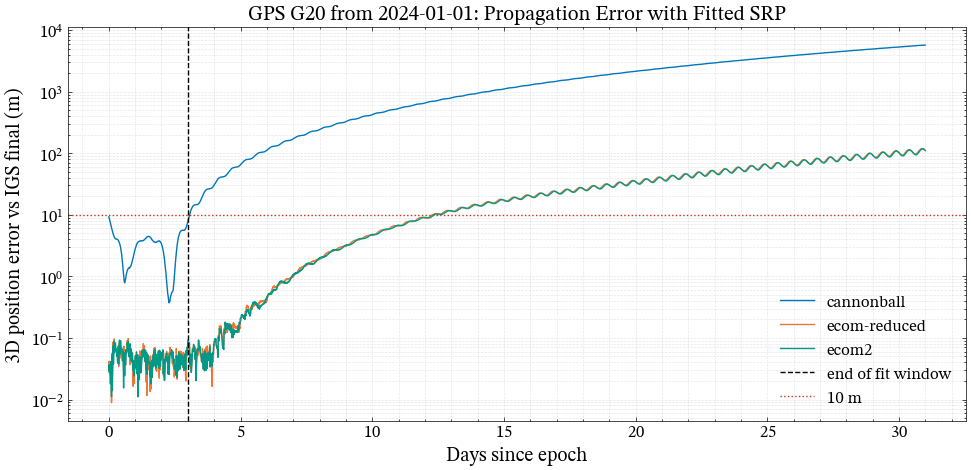

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, (err, _) in results.items():
    ax.semilogy(tdays, err, linewidth=1, label=name)
ax.axvline(FIT_DAYS, color="k", linestyle="--", linewidth=1, label="end of fit window")
ax.axhline(10, color="#CC3311", linestyle=":", linewidth=1, label="10 m")
ax.set_xlabel("Days since epoch")
ax.set_ylabel("3D position error vs IGS final (m)")
ax.set_title(f"GPS G{PRN:02d} from {START}: Propagation Error with Fitted SRP")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Benchmark: 24-hour predictions across the constellation

The IGS *ultra-rapid* product is the operational reference for short predictions: its predicted half is accurate to ~5 cm (1D RMS), and Duan & Hugentobler (2021) report 8–10 cm 3D for 24-hour predictions from 3-day arcs with CODE's full force model. To compare like with like, fit 2 days and predict the following 24 h for ten satellites across blocks, including two that cross Earth's shadow in this window (G08, G03 — propagated with Gauss–Jackson 8).

In [7]:
def beta_angle(pos, vel, t):
    h = np.cross(pos, vel); h /= np.linalg.norm(h)
    s = sk.sun.pos_gcrf(t); s /= np.linalg.norm(s)
    return np.degrees(np.arcsin(h @ s))


def in_shadow(t, p):
    s_hat = sk.sun.pos_gcrf(t); s_hat = s_hat / np.linalg.norm(s_hat)
    along = p @ s_hat
    return along < 0 and np.linalg.norm(p - along * s_hat) < sk.consts.earth_radius


gj8 = sk.propsettings()
for attr in ("gravity_degree", "gravity_order", "tide_model", "use_relativistic_correction", "use_spaceweather", "abs_error", "rel_error"):
    setattr(gj8, attr, getattr(settings, attr))
gj8.enable_interp = True
gj8.integrator = sk.integrator.gauss_jackson8   # immune to the shadow-boundary step-rejection abort
gj8.gj_step_seconds = 60.0

BENCH_FIT_DAYS, BENCH_PRNS = 2, [20, 5, 1, 14, 18, 11, 25, 30, 8, 3]
print(f"{'PRN':>4} {'beta':>6} {'shadow':>6}   {'cannonball':>15}   {'ecom-reduced':>15}   {'ecom2':>15}")
print(f"{'':>4} {'(deg)':>6} {'(%)':>6}   " + "   ".join([f"{'fit / 24 h (m)':>15}"] * 3))
bench = {name: [] for name in VARIANTS}
for prn in BENCH_PRNS:
    bt, bp = load_truth(START, BENCH_FIT_DAYS + 2, prn)
    nf = sum(1 for t in bt if t <= bt[0] + sk.duration.from_days(BENCH_FIT_DAYS))
    shadow = np.mean([in_shadow(t, p) for t, p in zip(bt, bp)])
    use = gj8 if shadow > 0 else settings
    row = []
    for name in VARIANTS:
        c0, cstep, build = VARIANTS[name]
        x0 = np.concatenate((bp[0] / 1e3, initial_velocity(bt, bp), c0))
        steps = np.array([1e-3] * 3 + [1e-4] * 3 + cstep)
        def resid(x, build=build):
            st = np.concatenate((x[:3] * 1e3, x[3:6]))
            res = sk.propagate(st, bt[0], bt[nf - 1], propsettings=use, satproperties=build(x[6:]))
            return (np.array(res.interp(bt[:nf]))[:, :3] - bp[:nf]).ravel()
        sol = least_squares(resid, x0, jac=lambda x, r=resid: approx_derivative(r, x, abs_step=steps),
                            x_scale="jac", ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=400)
        st = np.concatenate((sol.x[:3] * 1e3, sol.x[3:6]))
        res = sk.propagate(st, bt[0], bt[-1], propsettings=use, satproperties=build(sol.x[6:]))
        d = np.array(res.interp(bt))[:, :3] - bp
        days = np.array([(t - bt[0]).days for t in bt])
        m = (days >= BENCH_FIT_DAYS) & (days < BENCH_FIT_DAYS + 1)
        fit_rms = np.sqrt(np.mean(np.sum(sol.fun.reshape(-1, 3) ** 2, axis=1)))
        pred = np.sqrt(np.mean(np.sum(d[m] ** 2, axis=1)))
        bench[name].append(pred)
        row.append(f"{fit_rms:6.3f} / {pred:6.3f}")
    print(f"G{prn:02d} {beta_angle(bp[0], initial_velocity(bt, bp), bt[0]):>6.1f} {shadow * 100:>6.1f}   " + "   ".join(row))
print(f"{'median 24 h':>18}   " + "   ".join(f"{'':>8} {np.median(bench[n]):6.3f}" for n in VARIANTS))

 PRN   beta shadow        cannonball      ecom-reduced             ecom2
      (deg)    (%)    fit / 24 h (m)    fit / 24 h (m)    fit / 24 h (m)


G20   17.7    0.0    1.669 / 12.318    0.049 /  0.055    0.047 /  0.057


G05   14.2    0.0    0.780 /  5.808    0.048 /  0.062    0.044 /  0.062


G01   33.6    0.0    0.151 /  0.617    0.053 /  0.069    0.050 /  0.069


G14  -40.0    0.0    1.881 / 13.673    0.034 /  0.050    0.034 /  0.050


...

G11   32.2    0.0    1.545 / 11.080    0.047 /  0.075    0.044 /  0.070


G25  -42.0    0.0    0.146 /  0.507    0.041 /  0.057    0.040 /  0.053


G30  -75.9    0.0    0.162 /  0.857    0.043 /  0.102    0.042 /  0.108


G08    3.9    7.6    0.203 /  0.581    0.047 /  0.056    0.041 /  0.053


G03   12.9    0.8    0.182 /  0.522    0.042 /  0.220    0.041 /  0.219
       median 24 h             3.333             0.065             0.065


## What this shows

* **Inside the fit arc, ECOM tracks the IGS orbit at the level of the orbit's own accuracy** (~5 cm 3D over 3 days, ~8 cm over 7); the cannonball cannot do better than a few metres.
* **24-hour predictions are at the 6–7 cm level** (median over ten satellites, 2-day fits), against ~5 cm for the IGS ultra-rapid predicted product and 8–10 cm reported by Duan & Hugentobler (2021) from 3-day arcs with a full analysis-centre force model. G08, which spends 8% of the window in umbra (propagated with Gauss–Jackson 8), is no worse than the others; G03, which only grazes the penumbra, is the outlier at 22 cm.
* **Beyond a few days the error is almost entirely along-track** (the T column) and grows roughly as $t^2$ — the signature of a small, slowly changing acceleration bias. From a 3-day fit the 10 m line is crossed after about 12 days and the 30-day error is ~100 m; from a 7-day fit it is ~15 days and ~55–65 m.
* **Constant coefficients do not hold for a month.** The in-window fit RMS grows with arc length (5 → 8 cm for 3 → 7 days) and the B terms change between windows: the true SRP coefficients drift with the Sun elevation angle above the orbit plane, $\beta$, over weeks. This is why analysis centres re-estimate ECOM daily, and why ECOM2's extra harmonics do not help — the limitation is temporal, not spectral.

For prediction, treat ECOM as a **short-arc model**: fit on the most recent few days, expect centimetre-level accuracy for a day, metre-level for a week, and refit as new orbits arrive. A target such as "< 10 m over a month" is not reachable with fixed coefficients (nor is it with any operational product — the IGS ultra-rapid predictions are re-issued four times a day for the same reason). Rust users can supply per-arc coefficients through `SatProperties::srp_ecom`; from Python, run one `propagate` per arc.

An earlier version of this tutorial read the SP3 epochs as UTC; that 18 s error produced a 13 cm fit residual and 30 cm / 9 m errors at 1 / 7 days, which were (wrongly) attributed to model mismatch.

The script `python/examples/ecom_gps_validation.py` in the repository runs both the single-satellite analysis and the multi-satellite benchmark for any PRN, window and fit length from the command line.